# TROUPE SYSTEM LEVEL MODEL DEMO

## Model Overview

The system level model for Troupe is defined in  `Troupe_model.py`

In [1]:
from Troupe_model import Rover

C:\Users\mmohame2\Anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


The model architecture is as follows:

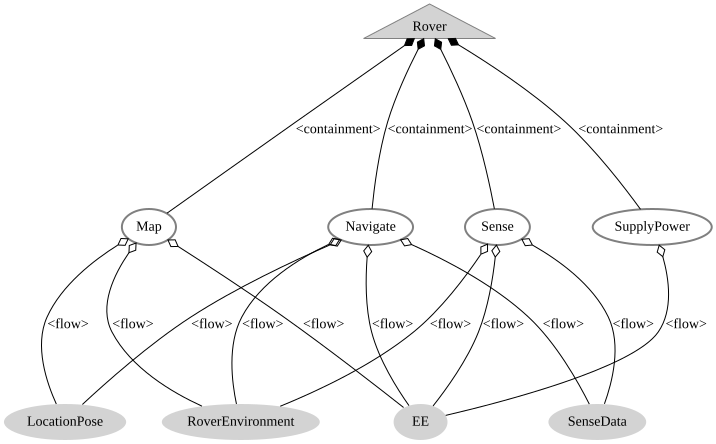

In [2]:
from fmdtools.analyze.graph.architecture import FunctionArchitectureFxnGraph, FunctionArchitectureTypeGraph

mdl = Rover()
mtg = FunctionArchitectureTypeGraph(mdl)
dot = mtg.draw_graphviz()

In [3]:
dot.render('troupe_function_architecture',format='pdf', view=False, cleanup = True)

'troupe_function_architecture.pdf'

The model takes three types of parameters:
* **Ground Control Parameters** are inputs from the control
* **Mission Parameters** are simulation parameters
* **Environment Parameters** are parameters to the grid map

In [4]:
mdl.p.ground_control

GroundControlParams(destination=(25, 25), dest_buffer=0.3, speed=0.1)

The ground control parameters include destination, and acceptable destination buffer, and the rovers maximum allowable speed

In [5]:
mdl.p.mission

MissionParams(loc_pos_error=0.1, num_waypoints=5, max_sense_delay=4, sense_malfunc_rate=0.3, vision_range=5.0, max_ghost_points=1)

Mission Parameters are as follows:
* `loc_pos_error` - the maximum error when estimating location and pose by the `Navigate` function. A random error between zero and max is added, which may compund over time steps until the `Sense` function sends the actual location and pose.
* `num_waypoints` - the number of way points the `Navigate` function will create within the visible range when calculating a path to destination.
* `max_sense_delay` - the maximum number of time steps the `Sense` function will have a delay in sensing the location and pose. A random number less than the max is chosen during the simulation.
* `sense_malfunc_rate` - the error rate when there is a malfunction in the `Sense` function.
* `vision_range` - this is the maximum range of the lidar/camera.
* `max_ghose_points` - This is a maximum number of ghost obstacles the simulation will create when the `Map` funtion has the `ghose_obstacle_detection` fault. A random number between 0 and this is chosen every timestep. 

In [14]:
mdl.p.environment

EnvironmentParams(x_size=100, y_size=100, blocksize=0.3, operator_params=GroundControlParams(destination=(25, 25), dest_buffer=0.3, speed=0.1), num_occupied=50, state_explored=(<class 'bool'>, False), state_perceived_objects=(<class 'bool'>, False), feature_occupied=(<class 'bool'>, False), feature_end_zone=(<class 'bool'>, False), point_base=(5.1, 5.1), collect_all_occupied=('occupied', True), collect_all_endzone=('end_zone', True))

Environment Parameters are as Follows:
* `x_size` - number of grid points in the x direction
* `y_size` - number of grid points in the y direction
* `blocksize` - size of a grid
* `operator_params` - the **Ground Control Parameters** which are used to create the end zone in the map
* `num_occupied` - number of gridpoints that are occupied by obstacles
* the remaining variables are attributes of the grid that we need to support the modeling

The grid is created based on these parameters, where the obstacles are randomly assigned in a way that 50 percent of the points form clusters of obstacles and the remaining 50 percent form individual obstacles.

The resulting grid looks like following, where the obstacles are the dots in the grid. 

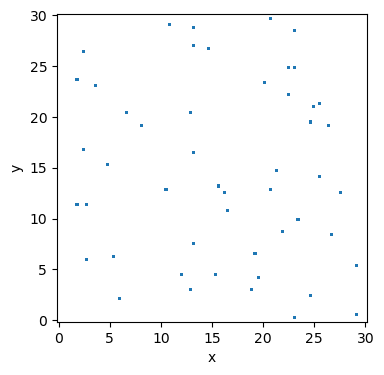

In [13]:
fig, ax = mdl.flows['environment'].c.show_collection('all_occupied', label = False)

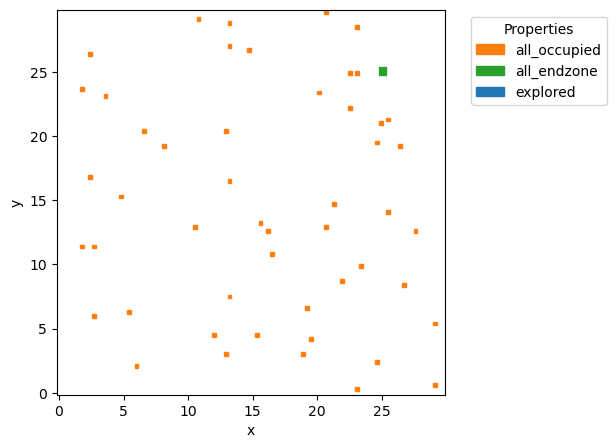

In [24]:
fig, ax = mdl.flows["environment"].c.show(
        {"explored": {}},
        collections={"all_occupied": {"label": False},
                      "all_endzone": {"label": False}},
        alpha=0.5, coll_overlay=False, linewidth = 0.0
    )

In [28]:
fig.savefig('Troupe_sample_map.pdf')
